In [1]:
import torch
print("GPU available:", torch.cuda.is_available())
print("Device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "none")

GPU available: True
Device name: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [3]:
import os

data_dir = os.path.expanduser("~/sonar-debris/data")
os.makedirs(data_dir, exist_ok=True)
print("Put SubPipe here:", data_dir)

Put SubPipe here: /home/illusive/sonar-debris/data


In [4]:
!pip install requests tqdm -q

import requests
from tqdm import tqdm
import os

record_id = "10808161"  # SubPipe's Zenodo record
resp = requests.get(f"https://zenodo.org/api/records/{record_id}")
files = resp.json()["files"]

for f in files:
    print(f["key"], "-", round(f["size"] / 1e9, 2), "GB")

SubPipe.zip - 27.85 GB
SubPipeMini.zip - 5.91 GB
SubPipeMini2.zip - 4.95 GB


In [5]:
download_url = None
for f in files:
    if f["key"] == "SubPipeMini2.zip":
        download_url = f["links"]["self"]
        total_size = f["size"]

zip_path = os.path.join(os.path.dirname(data_dir), "SubPipeMini2.zip")

resp = requests.get(download_url, stream=True)
with open(zip_path, "wb") as fh, tqdm(total=total_size, unit="B", unit_scale=True, desc="downloading") as pbar:
    for chunk in resp.iter_content(chunk_size=8192):
        fh.write(chunk)
        pbar.update(len(chunk))

print("saved to:", zip_path)


downloading: 100%|███████████████████████| 4.95G/4.95G [2:52:22<00:00, 478kB/s]

saved to: /home/illusive/sonar-debris/SubPipeMini2.zip


In [7]:
import zipfile, os

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(data_dir)

print(os.listdir(data_dir))

['SubPipeMiniSSS']


In [8]:
sss_root = os.path.join(data_dir, "SubPipeMiniSSS")

for root, dirs, filenames in os.walk(sss_root):
    depth = root.replace(sss_root, "").count(os.sep)
    if depth > 3:
        continue
    print("  " * depth + os.path.basename(root) + "/")
    for fn in filenames[:3]:
        print("  " * (depth + 1) + fn)
    if len(filenames) > 3:
        print("  " * (depth + 1) + f"... ({len(filenames)} files total)")
    

SubPipeMiniSSS/
  config.yaml
  DATA/
    Temperature.csv
    ForwardDistance.csv
    Altitude.csv
    ... (10 files total)
    SSS_HF_images/
      YOLO_Annotation/
        1693569576.819.txt
        1693569730.850.txt
        1693569796.860.txt
        ... (671 files total)
      Image/
        1693570095.970.pbm
        1693569908.930.pbm
        1693569459.790.pbm
        ... (1011 files total)
      COCO_Annotation/
        coco_format.json
    Cam0_images/
      1693573187.520.jpg
      1693572990.075.jpg
      1693573192.292.jpg
      ... (16200 files total)
    Cam1_images/
      1693573322.553.jpg
      1693573382.977.jpg
      1693573323.993.jpg
      ... (430 files total)
    SSS_LF_images/
      YOLO_Annotation/
        1693573377.819.txt
        1693569576.819.txt
        1693569730.850.txt
        ... (697 files total)
      Image/
        1693570095.970.pbm
        1693569908.930.pbm
        1693569459.790.pbm
        ... (1055 files total)
      COCO_Annotation/
       

In [9]:
import json
from collections import Counter

for freq in ["HF", "LF"]:
    coco_path = os.path.join(sss_root, "DATA", f"SSS_{freq}_images", "COCO_Annotation", "coco_format.json")
    with open(coco_path) as f:
        coco = json.load(f)

    cats = {c["id"]: c["name"] for c in coco["categories"]}
    counts = Counter(cats[ann["category_id"]] for ann in coco["annotations"])

    print(f"--- {freq} ---")
    print("categories:", cats)
    print("annotation counts:", dict(counts))
    print()

--- HF ---
categories: {1: 'Pipeline'}
annotation counts: {'Pipeline': 593}

--- LF ---
categories: {1: 'Pipeline'}
annotation counts: {'Pipeline': 726}



In [10]:
import os, shutil
from pathlib import Path
from PIL import Image

freq = "HF"
img_dir = Path(sss_root) / "DATA" / f"SSS_{freq}_images" / "Image"
label_dir = Path(sss_root) / "DATA" / f"SSS_{freq}_images" / "YOLO_Annotation"
out_root = Path(os.path.expanduser("~/sonar-debris/yolo_ready"))

# sort by timestamp (the filename itself), then split sequentially — NOT shuffled
img_paths = sorted(img_dir.glob("*.pbm"), key=lambda p: float(p.stem))
split_idx = int(len(img_paths) * 0.8)
splits = {"train": img_paths[:split_idx], "val": img_paths[split_idx:]}

counts = {"train": 0, "val": 0}
for split, paths in splits.items():
    for img_path in paths:
        stem = img_path.stem
        dst_img = out_root / split / "images" / f"{stem}.png"
        dst_img.parent.mkdir(parents=True, exist_ok=True)
        Image.open(img_path).convert("L").save(dst_img)

        dst_label = out_root / split / "labels" / f"{stem}.txt"
        dst_label.parent.mkdir(parents=True, exist_ok=True)
        src_label = label_dir / f"{stem}.txt"
        if src_label.exists():
            shutil.copy(src_label, dst_label)
        else:
            dst_label.touch()  # no pipe visible in this frame — valid negative example
        counts[split] += 1

yaml_content = f"""path: {out_root.resolve()}
train: train/images
val: val/images
names:
  0: Pipeline
"""
(out_root / "data.yaml").write_text(yaml_content)
print(counts)
print("wrote", out_root / "data.yaml")

{'train': 722, 'val': 181}
wrote /home/illusive/sonar-debris/yolo_ready/data.yaml


In [11]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # nano — fastest, good fit for a 6GB laptop GPU

model.train(
    data=str(out_root / "data.yaml"),
    epochs=30,           # short sanity run first
    imgsz=640,
    batch=8,              # conservative for 6GB VRAM — bump to 16 later if it fits
    dropout=0.1,          # keep >0 — needed later for MC Dropout confidence scoring
    hsv_h=0.0, hsv_s=0.0, # sonar is grayscale — color augmentation is meaningless here
    hsv_v=0.2,
    mosaic=0.3,
    mixup=0.0,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    shear=2.0,
    patience=15,
)

WARNING ⚠️ Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at '/home/illusive/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.133 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 5806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/illusive/sonar-debris/yolo_ready/data.yaml, degrees=10.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, drop

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f7d08fe5cd0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [12]:
results = model.predict(
    source=str(out_root / "val" / "images"),
    save=True,
    conf=0.25
)
print("saved predictions to:", results[0].save_dir)


image 1/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569952.939.png: 64x640 (no detections), 2.5ms
image 2/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569953.939.png: 64x640 (no detections), 2.6ms
image 3/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569954.939.png: 64x640 (no detections), 2.9ms
image 4/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569955.939.png: 64x640 1 Pipeline, 2.8ms
image 5/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569956.939.png: 64x640 (no detections), 3.0ms
image 6/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569957.939.png: 64x640 (no detections), 2.5ms
image 7/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569958.939.png: 64x640 (no detections), 2.6ms
image 8/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569959.939.png: 64x640 (no detections), 2.5ms
image 9/181 /home/illusive/sonar-debris/yolo_ready/val/images/1693569960.939.png: 64x640 (no detections), 2.

In [14]:
%matplotlib inline

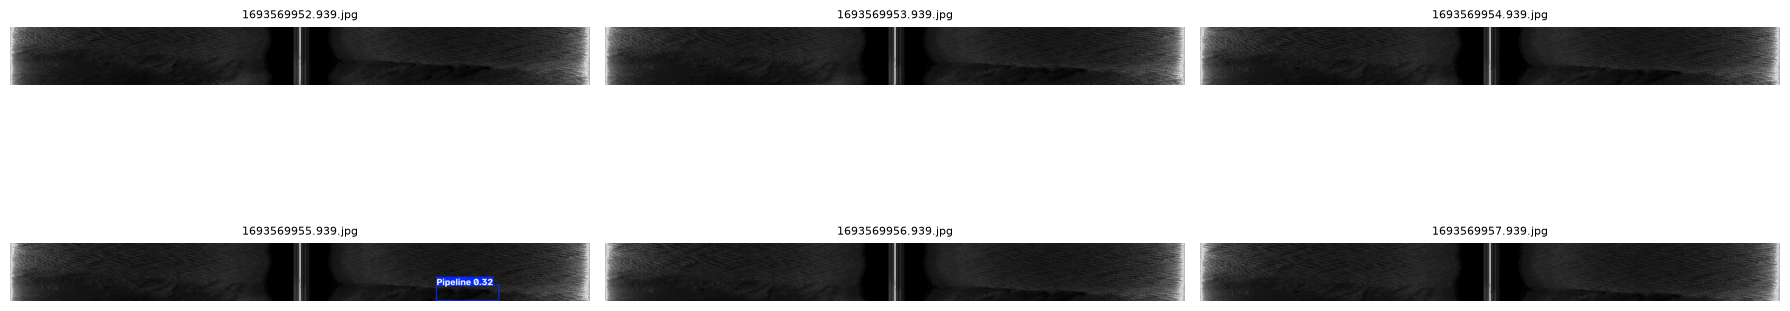

In [15]:
import matplotlib.pyplot as plt
from PIL import Image
import os

pred_dir = str(results[0].save_dir)
pred_images = sorted(os.listdir(pred_dir))[:6]  # first 6

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
for ax, fname in zip(axes.flat, pred_images):
    img = Image.open(os.path.join(pred_dir, fname))
    ax.imshow(img, cmap='gray')
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
import os
from pathlib import Path
from PIL import Image

def load_yolo_labels(label_path):
    """Returns list of (cls, xc, yc, w, h) all normalized 0-1, relative to full image."""
    if not label_path.exists():
        return []
    boxes = []
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls, xc, yc, w, h = int(parts[0]), *map(float, parts[1:])
                boxes.append((cls, xc, yc, w, h))
    return boxes

def tile_image_and_labels(img_path, label_path, out_img_dir, out_label_dir, tile_size=500, overlap=100):
    img = Image.open(img_path).convert("L")
    W, H = img.size
    boxes = load_yolo_labels(label_path)

    stride = tile_size - overlap
    x_starts = list(range(0, max(W - tile_size, 0) + 1, stride))
    if x_starts[-1] + tile_size < W:
        x_starts.append(W - tile_size)  # make sure the right edge is covered

    stem = img_path.stem
    for i, x0 in enumerate(x_starts):
        x1 = x0 + tile_size
        tile = img.crop((x0, 0, x1, H))

        tile_boxes = []
        for cls, xc, yc, w, h in boxes:
            abs_xc, abs_yc, abs_w, abs_h = xc * W, yc * H, w * W, h * H
            box_x0, box_x1 = abs_xc - abs_w / 2, abs_xc + abs_w / 2

            inter_x0, inter_x1 = max(box_x0, x0), min(box_x1, x1)
            if inter_x1 <= inter_x0:
                continue  # box doesn't overlap this tile at all

            overlap_frac = (inter_x1 - inter_x0) / abs_w
            if overlap_frac < 0.3:
                continue  # too sliver-thin a fragment to be a useful training example

            # clip box to tile bounds, convert back to tile-relative normalized coords
            new_xc = ((inter_x0 + inter_x1) / 2 - x0) / tile_size
            new_w = (inter_x1 - inter_x0) / tile_size
            tile_boxes.append((cls, new_xc, yc, new_w, h * H / tile_size))

        out_img_dir.mkdir(parents=True, exist_ok=True)
        out_label_dir.mkdir(parents=True, exist_ok=True)
        tile.save(out_img_dir / f"{stem}_tile{i}.png")
        with open(out_label_dir / f"{stem}_tile{i}.txt", "w") as f:
            for cls, xc, yc, w, h in tile_boxes:
                f.write(f"{cls} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

print("function defined")

function defined


In [28]:
def tile_image_and_labels_rect(
    img_path,
    label_path,
    out_img_dir,
    out_label_dir,
    tile_width=1000,
    tile_height=500,
    overlap=200
):
    img = Image.open(img_path).convert("L")
    W, H = img.size
    boxes = load_yolo_labels(label_path)

    # Horizontal sliding window
    stride = tile_width - overlap

    x_starts = list(
        range(
            0,
            max(W - tile_width, 0) + 1,
            stride
        )
    )

    # Make sure the right edge is always covered
    if not x_starts:
        x_starts = [0]

    if x_starts[-1] + tile_width < W:
        x_starts.append(W - tile_width)

    stem = img_path.stem

    for i, x0 in enumerate(x_starts):

        x1 = min(x0 + tile_width, W)

        # Full image height (500 px)
        tile = img.crop((x0, 0, x1, H))

        actual_tile_width = x1 - x0

        tile_boxes = []

        for cls, xc, yc, w, h in boxes:

            # Original normalized YOLO → absolute pixels
            abs_xc = xc * W
            abs_yc = yc * H
            abs_w = w * W
            abs_h = h * H

            # Original bounding-box boundaries
            box_x0 = abs_xc - abs_w / 2
            box_x1 = abs_xc + abs_w / 2

            # Intersection with tile
            inter_x0 = max(box_x0, x0)
            inter_x1 = min(box_x1, x1)

            if inter_x1 <= inter_x0:
                continue

            # How much of the original object remains?
            overlap_frac = (inter_x1 - inter_x0) / abs_w

            if overlap_frac < 0.3:
                continue

            # Convert clipped box to tile-relative coordinates
            new_xc = (
                ((inter_x0 + inter_x1) / 2 - x0)
                / actual_tile_width
            )

            new_w = (
                (inter_x1 - inter_x0)
                / actual_tile_width
            )

            # Vertical coordinates remain relative to full 500 px height
            new_yc = yc
            new_h = abs_h / H

            tile_boxes.append(
                (cls, new_xc, new_yc, new_w, new_h)
            )

        # Create output directories
        out_img_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        out_label_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        # Save tile
        tile.save(
            out_img_dir /
            f"{stem}_tile{i}.png"
        )

        # Save YOLO labels
        with open(
            out_label_dir /
            f"{stem}_tile{i}.txt",
            "w"
        ) as f:

            for cls, xc, yc, w, h in tile_boxes:
                f.write(
                    f"{cls} "
                    f"{xc:.6f} "
                    f"{yc:.6f} "
                    f"{w:.6f} "
                    f"{h:.6f}\n"
                )

print("✅ Rectangular tiling function defined")

✅ Rectangular tiling function defined


In [21]:
from pathlib import Path

# Original dataset
DATASET = Path("/home/illusive/sonar-debris/yolo_ready")

# New tiled dataset
TILED = Path("/home/illusive/sonar-debris/yolo_tiled")

# Make sure output directories exist
for split in ["train", "val"]:
    (TILED / split / "images").mkdir(parents=True, exist_ok=True)
    (TILED / split / "labels").mkdir(parents=True, exist_ok=True)

# Tile both train and validation sets
for split in ["train", "val"]:
    img_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    out_img_dir = TILED / split / "images"
    out_label_dir = TILED / split / "labels"

    images = sorted(img_dir.glob("*.png"))

    print(f"\n{split.upper()}: {len(images)} images")

    for n, img_path in enumerate(images, 1):
        label_path = label_dir / f"{img_path.stem}.txt"

        tile_image_and_labels(
            img_path,
            label_path,
            out_img_dir,
            out_label_dir,
            tile_size=500,
            overlap=100
        )

        if n % 50 == 0 or n == len(images):
            print(f"  processed {n}/{len(images)}")

print("\n✅ TILING COMPLETE")
print(f"Output: {TILED}")


TRAIN: 722 images
  processed 50/722
  processed 100/722
  processed 150/722
  processed 200/722
  processed 250/722
  processed 300/722
  processed 350/722
  processed 400/722
  processed 450/722
  processed 500/722
  processed 550/722
  processed 600/722
  processed 650/722
  processed 700/722
  processed 722/722

VAL: 181 images
  processed 50/181
  processed 100/181
  processed 150/181
  processed 181/181

✅ TILING COMPLETE
Output: /home/illusive/sonar-debris/yolo_tiled


In [22]:
from pathlib import Path
from PIL import Image

TILED = Path("/home/illusive/sonar-debris/yolo_tiled")

for split in ["train", "val"]:
    img_dir = TILED / split / "images"
    label_dir = TILED / split / "labels"

    images = sorted(img_dir.glob("*.png"))
    labels = sorted(label_dir.glob("*.txt"))

    print(f"\n{split.upper()}")
    print(f"Images : {len(images)}")
    print(f"Labels : {len(labels)}")

    # Check image dimensions
    sizes = {}
    for img_path in images[:100]:
        with Image.open(img_path) as im:
            sizes[im.size] = sizes.get(im.size, 0) + 1

    print("Image sizes (sample):", sizes)

    # Count labelled tiles and bounding boxes
    labelled_tiles = 0
    total_boxes = 0

    for label_path in labels:
        text = label_path.read_text().strip()

        if text:
            labelled_tiles += 1
            total_boxes += len(text.splitlines())

    print(f"Tiles containing objects: {labelled_tiles}")
    print(f"Total bounding boxes: {total_boxes}")


TRAIN
Images : 9386
Labels : 9386
Image sizes (sample): {(500, 500): 100}
Tiles containing objects: 966
Total bounding boxes: 966

VAL
Images : 2353
Labels : 2353
Image sizes (sample): {(500, 500): 100}
Tiles containing objects: 172
Total bounding boxes: 172


Labelled tiles available: 966


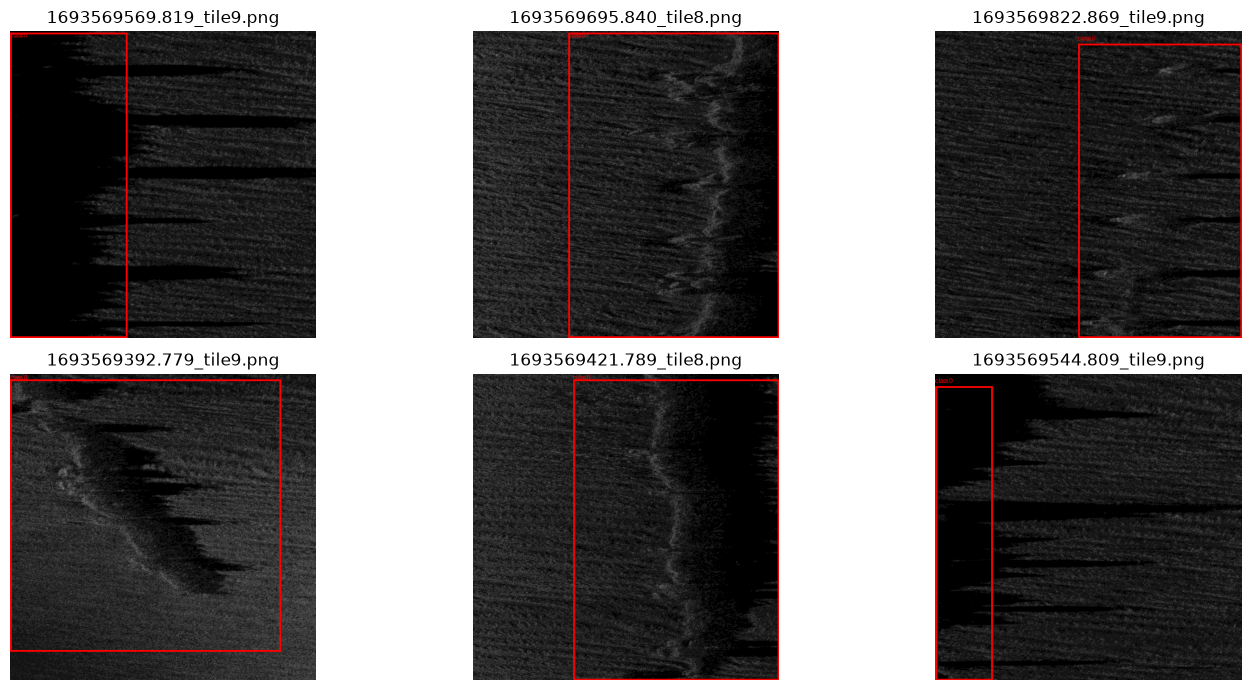

In [23]:
from pathlib import Path
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

TILED = Path("/home/illusive/sonar-debris/yolo_tiled")

# Pick random labelled training tiles
img_dir = TILED / "train" / "images"
label_dir = TILED / "train" / "labels"

labelled = []

for label_path in label_dir.glob("*.txt"):
    if label_path.read_text().strip():
        img_path = img_dir / f"{label_path.stem}.png"
        if img_path.exists():
            labelled.append((img_path, label_path))

print(f"Labelled tiles available: {len(labelled)}")

# Select up to 6 examples
samples = random.sample(labelled, min(6, len(labelled)))

fig, axes = plt.subplots(
    2, 3,
    figsize=(15, 7)
)

axes = axes.flatten()

for ax, (img_path, label_path) in zip(axes, samples):

    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    W, H = img.size

    for line in label_path.read_text().strip().splitlines():

        cls, xc, yc, w, h = map(float, line.split())

        # YOLO normalized → pixel coordinates
        xc *= W
        yc *= H
        w *= W
        h *= H

        x0 = xc - w / 2
        y0 = yc - h / 2
        x1 = xc + w / 2
        y1 = yc + h / 2

        draw.rectangle(
            [x0, y0, x1, y1],
            outline="red",
            width=3
        )

        draw.text(
            (x0, max(0, y0 - 15)),
            f"class {int(cls)}",
            fill="red"
        )

    ax.imshow(img, cmap="gray")
    ax.set_title(img_path.name)
    ax.axis("off")

# Hide unused axes
for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [24]:
from pathlib import Path
import numpy as np

ORIGINAL = Path("/home/illusive/sonar-debris/yolo_ready")
TILED = Path("/home/illusive/sonar-debris/yolo_tiled")

def label_stats(label_dir):
    widths = []
    heights = []
    boxes = 0

    for p in label_dir.glob("*.txt"):
        text = p.read_text().strip()

        if not text:
            continue

        for line in text.splitlines():
            parts = line.split()

            if len(parts) != 5:
                continue

            cls, xc, yc, w, h = map(float, parts)

            boxes += 1
            widths.append(w)
            heights.append(h)

    return boxes, widths, heights


for split in ["train", "val"]:
    print(f"\n{'='*50}")
    print(split.upper())

    # Original
    boxes, widths, heights = label_stats(
        ORIGINAL / split / "labels"
    )

    print("\nORIGINAL LABELS")
    print("Boxes:", boxes)

    if boxes:
        print(f"Width  mean: {np.mean(widths):.4f}")
        print(f"Width  min : {np.min(widths):.4f}")
        print(f"Width  max : {np.max(widths):.4f}")
        print(f"Height mean: {np.mean(heights):.4f}")
        print(f"Height min : {np.min(heights):.4f}")
        print(f"Height max : {np.max(heights):.4f}")

    # Tiled
    boxes, widths, heights = label_stats(
        TILED / split / "labels"
    )

    print("\nTILED LABELS")
    print("Boxes:", boxes)

    if boxes:
        print(f"Width  mean: {np.mean(widths):.4f}")
        print(f"Width  min : {np.min(widths):.4f}")
        print(f"Width  max : {np.max(widths):.4f}")
        print(f"Height mean: {np.mean(heights):.4f}")
        print(f"Height min : {np.min(heights):.4f}")
        print(f"Height max : {np.max(heights):.4f}")


TRAIN

ORIGINAL LABELS
Boxes: 505
Width  mean: 0.0907
Width  min : 0.0156
Width  max : 0.1420
Height mean: 0.9304
Height min : 0.1500
Height max : 0.9980

TILED LABELS
Boxes: 966
Width  mean: 0.5729
Width  min : 0.1560
Width  max : 1.0000
Height mean: 0.9342
Height min : 0.1500
Height max : 0.9980

VAL

ORIGINAL LABELS
Boxes: 88
Width  mean: 0.0698
Width  min : 0.0250
Width  max : 0.1046
Height mean: 0.7880
Height min : 0.1880
Height max : 0.9980

TILED LABELS
Boxes: 172
Width  mean: 0.4522
Width  min : 0.1180
Width  max : 0.9860
Height mean: 0.7834
Height min : 0.1880
Height max : 0.9980


In [26]:
from pathlib import Path

DATASET = Path("/home/illusive/sonar-debris/yolo_ready")
TILED_1000 = Path("/home/illusive/sonar-debris/yolo_tiled_1000")

for split in ["train", "val"]:
    (TILED_1000 / split / "images").mkdir(parents=True, exist_ok=True)
    (TILED_1000 / split / "labels").mkdir(parents=True, exist_ok=True)

for split in ["train", "val"]:

    img_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    out_img_dir = TILED_1000 / split / "images"
    out_label_dir = TILED_1000 / split / "labels"

    images = sorted(img_dir.glob("*.png"))

    print(f"\n{split.upper()}: {len(images)} images")

    for n, img_path in enumerate(images, 1):

        label_path = label_dir / f"{img_path.stem}.txt"

        tile_image_and_labels(
            img_path,
            label_path,
            out_img_dir,
            out_label_dir,
            tile_size=1000,
            overlap=200
        )

        if n % 50 == 0 or n == len(images):
            print(f"  processed {n}/{len(images)}")

print("\n✅ 1000×500 TILING COMPLETE")
print(f"Output: {TILED_1000}")


TRAIN: 722 images
  processed 50/722
  processed 100/722
  processed 150/722
  processed 200/722
  processed 250/722
  processed 300/722
  processed 350/722
  processed 400/722
  processed 450/722
  processed 500/722
  processed 550/722
  processed 600/722
  processed 650/722
  processed 700/722
  processed 722/722

VAL: 181 images
  processed 50/181
  processed 100/181
  processed 150/181
  processed 181/181

✅ 1000×500 TILING COMPLETE
Output: /home/illusive/sonar-debris/yolo_tiled_1000


In [27]:
import inspect

print(inspect.getsource(tile_image_and_labels))

def tile_image_and_labels(img_path, label_path, out_img_dir, out_label_dir, tile_size=500, overlap=100):
    img = Image.open(img_path).convert("L")
    W, H = img.size
    boxes = load_yolo_labels(label_path)

    stride = tile_size - overlap
    x_starts = list(range(0, max(W - tile_size, 0) + 1, stride))
    if x_starts[-1] + tile_size < W:
        x_starts.append(W - tile_size)  # make sure the right edge is covered

    stem = img_path.stem
    for i, x0 in enumerate(x_starts):
        x1 = x0 + tile_size
        tile = img.crop((x0, 0, x1, H))

        tile_boxes = []
        for cls, xc, yc, w, h in boxes:
            abs_xc, abs_yc, abs_w, abs_h = xc * W, yc * H, w * W, h * H
            box_x0, box_x1 = abs_xc - abs_w / 2, abs_xc + abs_w / 2

            inter_x0, inter_x1 = max(box_x0, x0), min(box_x1, x1)
            if inter_x1 <= inter_x0:
                continue  # box doesn't overlap this tile at all

            overlap_frac = (inter_x1 - inter_x0) / abs_w
            

In [29]:
from pathlib import Path

DATASET = Path("/home/illusive/sonar-debris/yolo_ready")
TILED_1000 = Path("/home/illusive/sonar-debris/yolo_tiled_1000")

for split in ["train", "val"]:

    img_dir = DATASET / split / "images"
    label_dir = DATASET / split / "labels"

    out_img_dir = TILED_1000 / split / "images"
    out_label_dir = TILED_1000 / split / "labels"

    images = sorted(img_dir.glob("*.png"))

    print(f"\n{split.upper()}: {len(images)} images")

    for n, img_path in enumerate(images, 1):

        label_path = label_dir / f"{img_path.stem}.txt"

        tile_image_and_labels_rect(
            img_path,
            label_path,
            out_img_dir,
            out_label_dir,
            tile_width=1000,
            tile_height=500,
            overlap=200
        )

        if n % 50 == 0 or n == len(images):
            print(f"  processed {n}/{len(images)}")

print("\n✅ 1000×500 TILING COMPLETE")
print(f"Output: {TILED_1000}")


TRAIN: 722 images
  processed 50/722
  processed 100/722
  processed 150/722
  processed 200/722
  processed 250/722
  processed 300/722
  processed 350/722
  processed 400/722
  processed 450/722
  processed 500/722
  processed 550/722
  processed 600/722
  processed 650/722
  processed 700/722
  processed 722/722

VAL: 181 images
  processed 50/181
  processed 100/181
  processed 150/181
  processed 181/181

✅ 1000×500 TILING COMPLETE
Output: /home/illusive/sonar-debris/yolo_tiled_1000


In [30]:
from pathlib import Path
from PIL import Image
import numpy as np

TILED = Path("/home/illusive/sonar-debris/yolo_tiled_1000")

def get_stats(label_dir):
    widths = []
    heights = []
    boxes = 0
    labelled_tiles = 0

    for p in label_dir.glob("*.txt"):
        text = p.read_text().strip()

        if not text:
            continue

        labelled_tiles += 1

        for line in text.splitlines():
            parts = line.split()

            if len(parts) != 5:
                continue

            cls, xc, yc, w, h = map(float, parts)

            boxes += 1
            widths.append(w)
            heights.append(h)

    return labelled_tiles, boxes, widths, heights


for split in ["train", "val"]:

    img_dir = TILED / split / "images"
    label_dir = TILED / split / "labels"

    images = sorted(img_dir.glob("*.png"))
    labels = sorted(label_dir.glob("*.txt"))

    print("\n" + "=" * 50)
    print(split.upper())

    print("Images:", len(images))
    print("Labels:", len(labels))

    # Check image dimensions
    sizes = {}

    for img_path in images[:100]:
        with Image.open(img_path) as im:
            sizes[im.size] = sizes.get(im.size, 0) + 1

    print("Image sizes:", sizes)

    labelled_tiles, boxes, widths, heights = get_stats(label_dir)

    print("Tiles containing objects:", labelled_tiles)
    print("Total bounding boxes:", boxes)

    if boxes:
        print(f"Box width  mean: {np.mean(widths):.4f}")
        print(f"Box width  min : {np.min(widths):.4f}")
        print(f"Box width  max : {np.max(widths):.4f}")
        print(f"Box height mean: {np.mean(heights):.4f}")
        print(f"Box height min : {np.min(heights):.4f}")
        print(f"Box height max : {np.max(heights):.4f}")


TRAIN
Images: 4332
Labels: 4332
Image sizes: {(1000, 500): 100}
Tiles containing objects: 568
Total bounding boxes: 568
Box width  mean: 0.4249
Box width  min : 0.0780
Box width  max : 0.7100
Box height mean: 0.9244
Box height min : 0.1500
Box height max : 0.9980

VAL
Images: 1086
Labels: 1086
Image sizes: {(1000, 500): 100}
Tiles containing objects: 88
Total bounding boxes: 88
Box width  mean: 0.3490
Box width  min : 0.1250
Box width  max : 0.5230
Box height mean: 0.7880
Box height min : 0.1880
Box height max : 0.9980


Labelled tiles: 568


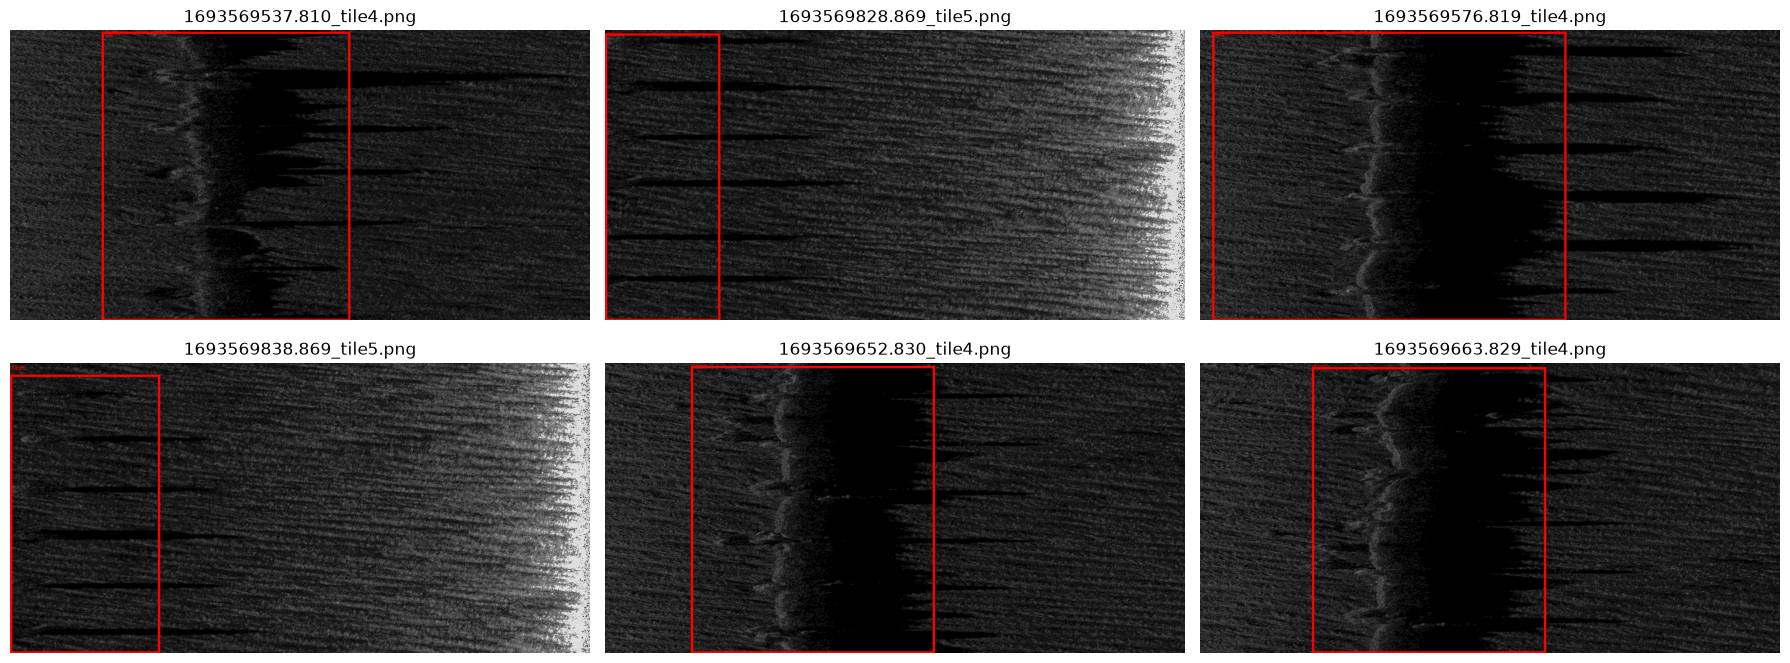

In [31]:
from pathlib import Path
from PIL import Image, ImageDraw
import random
import matplotlib.pyplot as plt

TILED = Path("/home/illusive/sonar-debris/yolo_tiled_1000")

img_dir = TILED / "train" / "images"
label_dir = TILED / "train" / "labels"

labelled = []

for label_path in label_dir.glob("*.txt"):
    if label_path.read_text().strip():
        img_path = img_dir / f"{label_path.stem}.png"

        if img_path.exists():
            labelled.append((img_path, label_path))

print("Labelled tiles:", len(labelled))

samples = random.sample(labelled, min(6, len(labelled)))

fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 7)
)

axes = axes.flatten()

for ax, (img_path, label_path) in zip(axes, samples):

    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img)

    W, H = img.size

    for line in label_path.read_text().strip().splitlines():

        cls, xc, yc, w, h = map(float, line.split())

        # YOLO normalized → pixels
        xc *= W
        yc *= H
        w *= W
        h *= H

        x0 = xc - w / 2
        y0 = yc - h / 2
        x1 = xc + w / 2
        y1 = yc + h / 2

        draw.rectangle(
            [x0, y0, x1, y1],
            outline="red",
            width=4
        )

        draw.text(
            (x0, max(0, y0 - 18)),
            f"class {int(cls)}",
            fill="red"
        )

    ax.imshow(img)
    ax.set_title(img_path.name)
    ax.axis("off")

for ax in axes[len(samples):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [32]:
from pathlib import Path
import yaml

TILED = Path("/home/illusive/sonar-debris/yolo_tiled_1000")

data = {
    "path": str(TILED),
    "train": "train/images",
    "val": "val/images",
    "nc": 1,
    "names": ["Pipeline"]
}

yaml_path = TILED / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print(yaml_path)
print("\n--- data.yaml ---")

print(yaml_path.read_text())

/home/illusive/sonar-debris/yolo_tiled_1000/data.yaml

--- data.yaml ---
path: /home/illusive/sonar-debris/yolo_tiled_1000
train: train/images
val: val/images
nc: 1
names:
- Pipeline



In [33]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data="/home/illusive/sonar-debris/yolo_tiled_1000/data.yaml",

    # First proper training run
    epochs=50,
    imgsz=640,
    batch=8,

    # Preserve the sonar aspect ratio during training
    rect=True,

    # Conservative augmentation for sonar
    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.2,
    mosaic=0.3,
    mixup=0.0,
    degrees=10.0,
    translate=0.1,
    scale=0.3,
    shear=2.0,

    # Training control
    patience=15,

    # Don't overwrite your previous experiment
    project="/home/illusive/Documents/SIH/runs/detect",
    name="pipeline_tiled_1000x500",
    exist_ok=True,

    # Your RTX 3050 6GB
    device=0
)

Ultralytics 8.4.133 🚀 Python-3.12.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 5806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/illusive/sonar-debris/yolo_tiled_1000/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.0, hsv_s=0.0, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.3, multi

In [34]:
from ultralytics import YOLO
from pathlib import Path

# Load the best model from your training run
model = YOLO(
    "/home/illusive/Documents/SIH/runs/detect/pipeline_tiled_1000x500/weights/best.pt"
)

# Validation tiles
val_images = "/home/illusive/sonar-debris/yolo_tiled_1000/val/images"

# Run inference
results = model.predict(
    source=val_images,
    save=True,
    conf=0.25,
    device=0,
    project="/home/illusive/Documents/SIH/runs/detect",
    name="pipeline_tiled_1000x500_predictions",
    exist_ok=True
)

print("✅ Predictions complete")
print("Saved to:", results[0].save_dir)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1086 /home/illusive/sonar-debris/yolo_tiled_1000/val/images/1693569952.939_tile0.png: 320x640 (no detections), 2.9ms
image 2/1086 /home/illusive/sonar-debris/yolo_tiled_1000/val/images/1693569952.939_tile1.png: 320x640 (no detections), 3.0ms
image 3/1086 /home/illusive/sonar-debris/yolo_tiled_1000/val/images/1693569952.939_tile2.png: 320x640 (no detections), 3.0ms
image 4/1086 /home/illusive/sonar-debris/yolo_tiled_1000/val/images/1693569952.939_t

Tiles with detections: 72


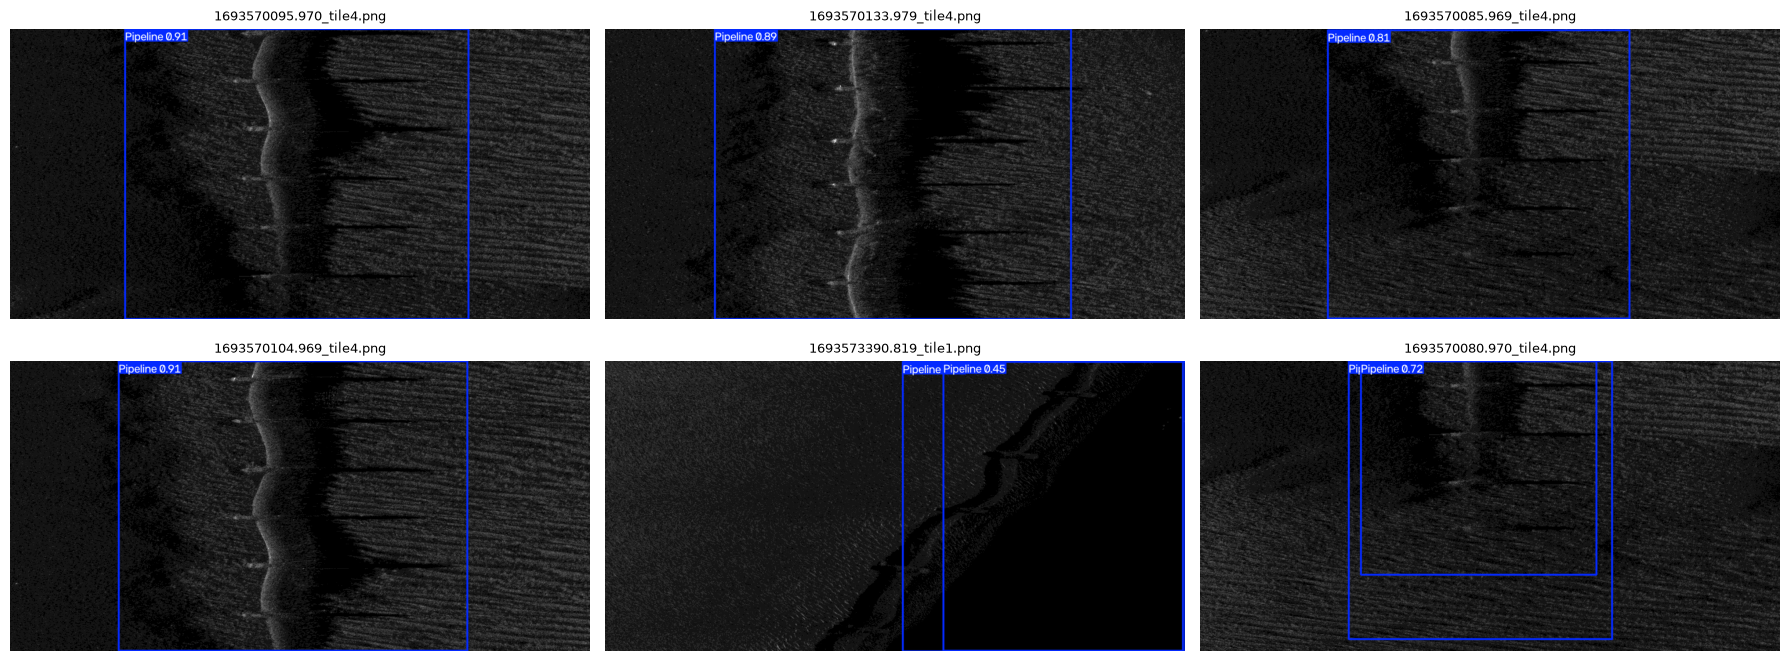

In [35]:
import random
from pathlib import Path
import matplotlib.pyplot as plt

# Keep only images where YOLO detected something
detected = [r for r in results if len(r.boxes) > 0]

print("Tiles with detections:", len(detected))

if not detected:
    print("No detections found.")
else:
    samples = random.sample(detected, min(6, len(detected)))

    fig, axes = plt.subplots(2, 3, figsize=(18, 7))
    axes = axes.flatten()

    for ax, r in zip(axes, samples):
        plotted = r.plot()

        # Ultralytics plot() returns BGR; matplotlib expects RGB
        ax.imshow(plotted[..., ::-1])
        ax.set_title(Path(r.path).name, fontsize=9)
        ax.axis("off")

    for ax in axes[len(samples):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [36]:
# Summary of confidence scores and number of detections

import numpy as np

all_conf = []
num_boxes = []

for r in results:
    if len(r.boxes) > 0:
        confs = r.boxes.conf.cpu().numpy()
        all_conf.extend(confs)
        num_boxes.append(len(confs))

print("Validation tiles:", len(results))
print("Tiles with detections:", len(detected))

if all_conf:
    print(f"Total detections: {len(all_conf)}")
    print(f"Mean confidence: {np.mean(all_conf):.3f}")
    print(f"Min confidence: {np.min(all_conf):.3f}")
    print(f"Max confidence: {np.max(all_conf):.3f}")
    print(f"Median confidence: {np.median(all_conf):.3f}")

print("\nDetection count distribution:")
for n in sorted(set(num_boxes)):
    print(f"  {n} detection(s): {num_boxes.count(n)} tiles")

Validation tiles: 1086
Tiles with detections: 72
Total detections: 77
Mean confidence: 0.754
Min confidence: 0.267
Max confidence: 0.915
Median confidence: 0.869

Detection count distribution:
  1 detection(s): 67 tiles
  2 detection(s): 5 tiles
